### Task 1: Designing a Heuristic for a Warehouse Robot

In [1]:
import math
import networkx as nx
import matplotlib.pyplot as plt


# 1. Coordinates of warehouse locations

locations = {
    "Receiving_Area": (0, 0),
    "Storage_A": (2, 1),
    "Storage_B": (1, 4),
    "Sorting_Area": (4, 2),
    "Inspection_Area": (5, 5),
    "Packing_Station": (7, 6)
}


# 2. Weighted warehouse graph

warehouse_graph = {
    "Receiving_Area": {
        "Storage_A": 2.2,
        "Storage_B": 4.1
    },

    "Storage_A": {
        "Sorting_Area": 2.2
    },

    "Storage_B": {
        "Inspection_Area": 5.0,
        "Sorting_Area": 6.0
    },

     # add remaining nodes and their connections as given in the lab task document.

    "Sorting_Area": {
        "Packing_Station": 5.0,
        "Inspection_Area": 3.2
    },

    "Inspection_Area": {
        "Packing_Station": 2.2
    }

}


# 3. Euclidean heuristic


def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
    return distance



# 4. Calculate heuristic values

goal = "Packing_Station"

print("Heuristic Values")
print("----------------")

for location in locations:
    h_value = heuristic(location, goal)
    print(f"Heuristic value from {location} to {goal}: {h_value:.2f}")

Heuristic Values
----------------
Heuristic value from Receiving_Area to Packing_Station: 9.22
Heuristic value from Storage_A to Packing_Station: 7.07
Heuristic value from Storage_B to Packing_Station: 6.32
Heuristic value from Sorting_Area to Packing_Station: 5.00
Heuristic value from Inspection_Area to Packing_Station: 2.24
Heuristic value from Packing_Station to Packing_Station: 0.00


#### NetworkX visualization: Since Task 1 does not ask GBFS/A* to find a path, you are supposed highlight the actual minimum-cost path merely for visualization:

In [2]:
# 5. Create NetworkX graph

G = nx.DiGraph()

for node, neighbors in warehouse_graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)

# 6. Find minimum-cost path
## The primary function to find the shortest path in the Python networkx library 
### 1. Unweighted shortest path (ignores 'weight', finds fewest number of edges)
### 2. Weighted shortest path (minimizes the sum of the 'weight' attribute)
solution_path = nx.shortest_path( # reaturn the path e.g. A → B → C
    G,#pass the graph object
    source="Receiving_Area",
    target="Packing_Station",
    weight="weight"
)

solution_cost = nx.shortest_path_length( #return the numeric value
     G,
        source="Receiving_Area",
        target="Packing_Station",
        weight="weight"
)

print("\nMinimum cost path:")
print(" -> ".join(solution_path))
print(f"Total cost: {solution_cost:.2f}")


Minimum cost path:
Receiving_Area -> Storage_A -> Sorting_Area -> Packing_Station
Total cost: 9.40


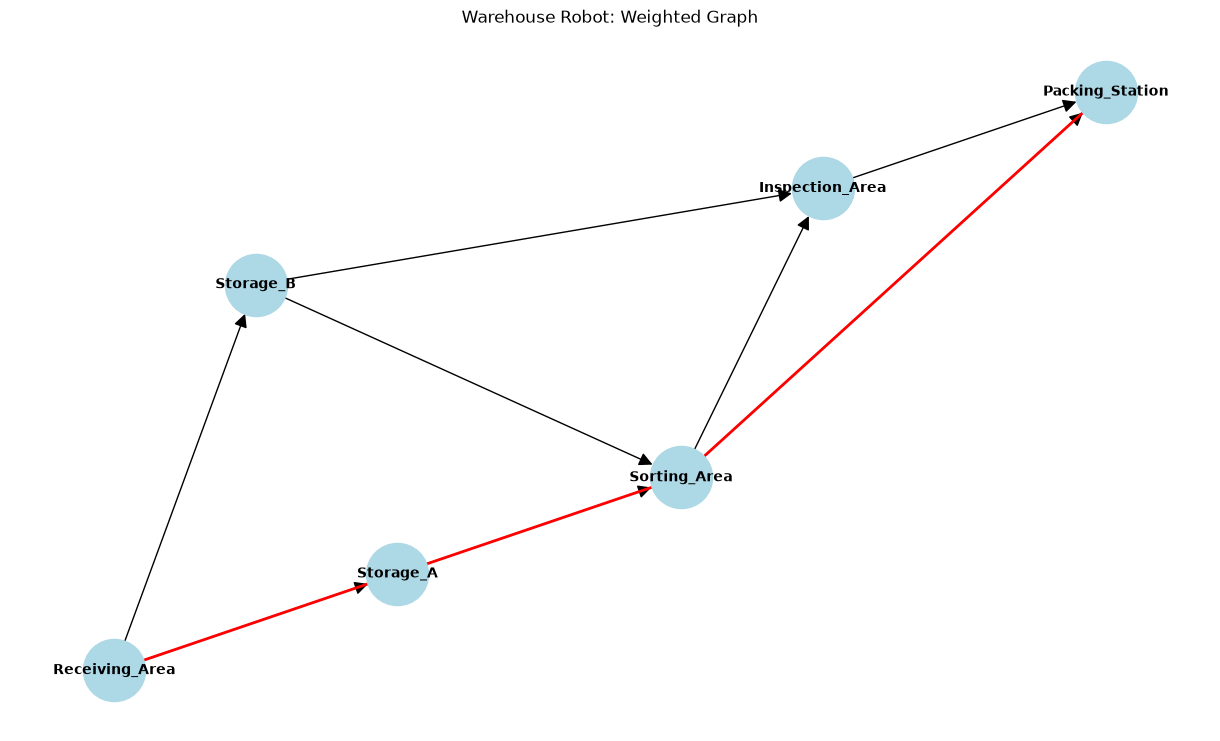

In [4]:
# 7. Visualize graph

pos = locations

plt.figure(figsize=(12, 7))

# write code to draw the graph with nodes, edges, and labels along with the highlighted solution path.
nx.draw(G,pos,with_labels=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
path_edges = list(zip(solution_path[:-1], solution_path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)
plt.title("Warehouse Robot: Weighted Graph")
plt.axis("off")
plt.show()

In [6]:
# 8. Verify heuristic condition

print("\nHeuristic Condition Verification")
print("***********************************")

for node in warehouse_graph:

    h_node = heuristic(node, "Packing_Station")

    for neighbor, cost in warehouse_graph[node].items():
        if ( h_node > cost + heuristic(neighbor, "Packing_Station") ):
            print(f"Heuristic condition failed for {node} -> {neighbor}")
        


Heuristic Condition Verification
***********************************
Heuristic condition failed for Inspection_Area -> Packing_Station


write down your observation in one line:

the heuristic condition failed from inspection area to the packign area 

### Task 2: Greedy Best-First Search for Airport Baggage Handling

In [9]:
import math
import heapq
from multiprocessing import heap
import networkx as nx
import matplotlib.pyplot as plt

# 1. Airport coordinates

locations = {
    "Baggage_Area": (0, 0),
    "Security": (2, 1),
    "Checkpoint": (1, 4),
    "Food_Court": (4, 2),
    # add remaining nodes and their coordinates as given in the lab task document.
    "Terminal_Hall" : (5,5),
    "Departure_Gate": (8,6)

}

# 2. Weighted graph


airport_graph = {
    "Baggage_Area": {
        "Security": 2.2,
        "Checkpoint": 4.1
    },

    "Security": {
        "Food_Court": 2.2
    },

    "Checkpoint": {
        "Terminal_Hall": 5.0
    },

    "Food_Court": {
        "Terminal_Hall": 3.2,
        "Departure_Gate": 6.0
    },

    "Terminal_Hall": {
        "Departure_Gate": 3.2
    },

    "Departure_Gate": {}
}

# 3. Euclidean heuristic


def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
    return distance
    


# 4. GBFS


def greedy_best_first_search(start, goal, graph):
    pq = []
    pq.append((heuristic(start, goal), start))

    expansion_order = []
    parent = {
        start: None
    }

    cost_so_far = {
        start: 0
    }

    visited = set()

    while pq:
        current_h, current_node = heapq.heappop(pq)
        expansion_order.append(current_node)

        if current_node == goal:
            break

        if current_node in visited:
            continue

        visited.add(current_node)

        for neighbor, cost in graph[current_node].items():
            if neighbor not in visited:
                new_cost = cost_so_far[current_node] + cost
                if neighbor not in visited or new_cost < cost_so_far[neighbor]:
                    cost_so_far[neighbor] = new_cost
                    parent[neighbor] = current_node
                    heapq.heappush(pq, (heuristic(neighbor, goal), neighbor))

    # write code to implement the Greedy Best-First Search algorithm using a priority queue (min-heap) 
    # to explore nodes based on their heuristic values. Keep track of the path and expansion order.
    
    
    

    # Reconstruct path
    path = []
    node = goal 
    while node is not None:
        path.append(node)
        node = parent[node]
    path.reverse()


    # Calculate actual path cost
    for node in path:
        if node != start:
            total_cost = cost_so_far[node]


    return expansion_order, path, total_cost
# 5. Run GBFS


# define the start state 
start = "Baggage_Area"
# define the goal state
goal = "Departure_Gate"

# call the greedy_best_first_search function with the start state, goal state, and airport_graph as arguments
expansion_order, path, total_cost = greedy_best_first_search(start, goal, airport_graph)
print("GBFS")
print("--------------------------------")
print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")

GBFS
--------------------------------
Expansion order:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Solution path:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Total path cost: 12.30


#### NetworkX visualization

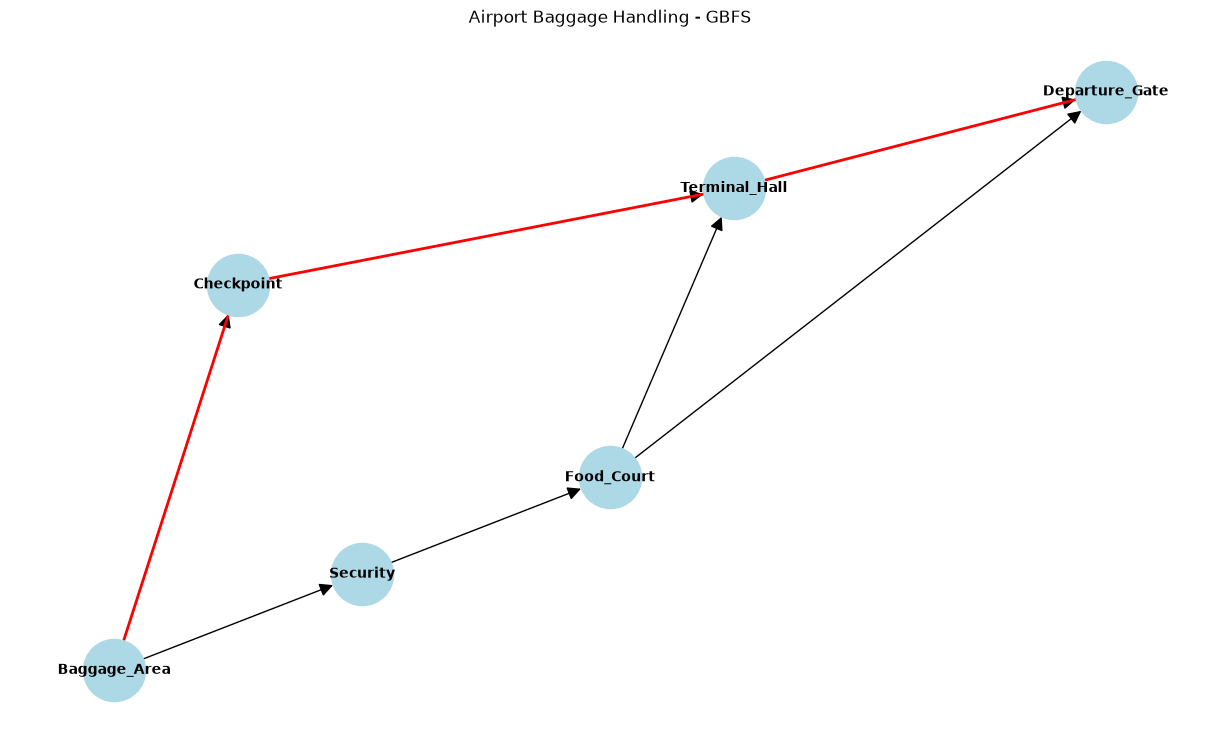

In [13]:
# 6. NetworkX visualization

G = nx.DiGraph()

for node, neighbors in airport_graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)


pos = locations

plt.figure(figsize=(12, 7))

# write code to draw the graph with nodes, edges, and labels along with the highlighted solution path.
nx.draw(G,pos,with_labels=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)
plt.title("Airport Baggage Handling - GBFS")
plt.axis("off")
plt.show()

### Task 3: A* Search for Emergency Supply Robot

In [27]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt


# 1. Hospital coordinates


locations = {
    "Pharmacy": (0, 0),
    "Main_Corridor": (2, 1),
    "Patient_Wing": (1, 4),
    "Nursing_Station": (4, 2),
    "Laboratory": (5, 5),
    "Emergency_Ward": (8, 6)
}


# 2. Hospital weighted graph


hospital_graph = {
    "Pharmacy": {
        "Main_Corridor": 2.2,
        "Patient_Wing": 4.1
    },

    "Main_Corridor": {
        "Nursing_Station": 2.2
    },

    "Patient_Wing": {
        "Laboratory": 5.0
    },

    # add remaining nodes and their connections as given in the lab task document.
    
    "Nursing_Station": {
        "Laboratory": 3.2,
        "Emergency_Ward": 6.0
    },

    "Laboratory": {
        "Emergency_Ward": 3.2
    }


}

# 3. Euclidean heuristic


def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
    return distance

# 4. Path reconstruction

def reconstruct_path(came_from, current):
    path = []
    while current is not None:
        path.append(current)
        current = came_from[current]
    path.reverse()
    return path

# 5. A* Search
def a_star_search(start, goal, graph):
    # write code to implement the A* Search algorithm using a priority queue (min-heap) 
    # to explore nodes based on their f(n) = g(n) + h(n) values. Keep track of the path, expansion order, and g(n) costs.
    pq = []
    g = {start: 0}
    
    pq.append((heuristic(start, goal), start))

    parent = {
        start: None
    }

    expansion_order = []

    visited = set()

    while pq:
            current_h, current_node = heapq.heappop(pq)
            expansion_order.append(current_node)
    
            if current_node == goal:
                break
    
            if current_node in visited:
                continue
    
            visited.add(current_node)
    
            for neighbor, cost in graph[current_node].items():
                tentative_g = g[current_node] + cost
                if neighbor not in visited or tentative_g < g[neighbor]:
                    g[neighbor] = tentative_g
                    parent[neighbor] = current_node
                    f = tentative_g + heuristic(neighbor, goal)
                    heapq.heappush(pq, (f, neighbor))


    path = reconstruct_path(parent, goal)
    total_cost = g[goal]

    print("\nA* Node Information")
    print("*********************")
    print(
            f"{'Node':20s}" #'Node' → the text to print, 20 → use 20 spaces/characters of width, s → treat it as a string
            f"{'g(n)':>10s}"
            f"{'h(n)':>10s}"
            f"{'f(n)':>10s}"
        )
    
    for node in expansion_order:
        g_cost = g[node]
        h = heuristic(node, goal)
        f = g_cost + h
    
        print(
            f"{node:20s}"
            f"{g_cost:10.2f}"
            f"{h:10.2f}"
            f"{f:10.2f}"
        )
    
    return expansion_order, path, total_cost
# 6. Run A*

# define the start state
start = "Pharmacy"
# define the goal state
goal = "Emergency_Ward"

# call the a_star_search function with the start state, goal state, and hospital_graph as arguments
expansion_order, path, total_cost = a_star_search(start, goal, hospital_graph)
print("A* Search")
print("--------------------------------")

print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")



A* Node Information
*********************
Node                      g(n)      h(n)      f(n)
Pharmacy                  0.00     10.00     10.00
Main_Corridor             2.20      7.81     10.01
Nursing_Station           4.40      5.66     10.06
Emergency_Ward           10.40      0.00     10.40
A* Search
--------------------------------
Expansion order:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Solution path:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Total path cost: 10.40


#### g(n), h(n), f(n) table

In [18]:
# you may also replace it with dataframe it is completely your own choice

print("\nA* Node Information")
print("*********************")
print(
    f"{'Node':20s}" #'Node' → the text to print, 20 → use 20 spaces/characters of width, s → treat it as a string
    f"{'g(n)':>10s}"
    f"{'h(n)':>10s}"
    f"{'f(n)':>10s}"
)

for node in expansion_order:

    g = g[node]
    h = heuristic(node, goal)
    f = g + h

    print(
        f"{node:20s}"
        f"{g:10.2f}"
        f"{h:10.2f}"
        f"{f:10.2f}"
    )


A* Node Information
*********************
Node                      g(n)      h(n)      f(n)


NameError: name 'g' is not defined

#### NetworkX visualization

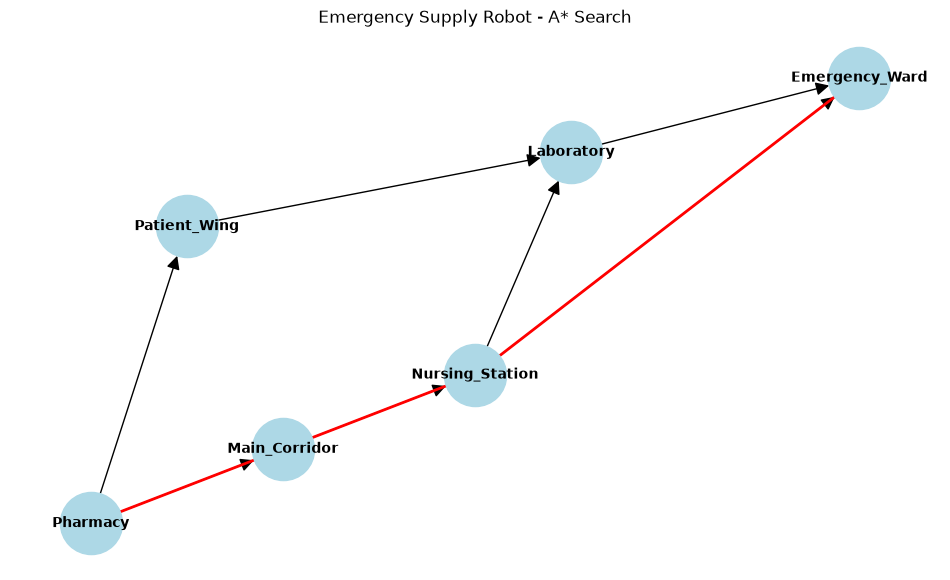

In [28]:
# 7. NetworkX visualization
G = nx.DiGraph()

for node, neighbors in hospital_graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)


pos = locations

plt.figure(figsize=(12, 7))

# write code to draw the graph with nodes, edges, and labels along with the highlighted solution path.
nx.draw_networkx(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)

plt.title("Emergency Supply Robot - A* Search")
plt.axis("off")
plt.show()

GBFS would primarily ask:

"Which node appears closest to the Emergency Ward?"

A* instead asks:

"Considering both the cost already travelled and the estimated remaining cost, which node has the lowest estimated total cost?"

### Task 4: Weighted A* for Autonomous Delivery Drone

In [36]:
import math
import heapq
import pandas as pd

# 1. Location Coordinates

locations = {
    "Distribution_Center": (0, 0),
    "Zone_A": (2, 1),
    "Zone_B": (1, 4),
    # add remaining nodes and their coordinates as given in the lab task document.
    "Zone_C": (4, 2),
    "Zone_D": (5, 5),
    "Customer_Building": (8, 6)
}

# 2. Weighted Graph

graph = {
    "Distribution_Center": {
        "Zone_A": 2.2,
        "Zone_B": 3.0
    },

    "Zone_A": {
        "Zone_C": 2.2
    },

    "Zone_B": {
        "Zone_D": 5.0
    },
    
    # add remaining nodes and their connections as given in the lab task document.
    "Zone_C" : {
        "Zone_D" : 3.2,
        "Customer_Building": 6.0
    },

    "Zone_D": {
        "Customer_Building": 3.2
    }

}

# 3. Euclidean Heuristic

def heuristic(node, goal):
    x1, y1 = locations[node]
    x2, y2 = locations[goal]
    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
    return distance

# 4. Display Heuristic Values
goal = "Customer_Building"

heuristic_data = []

for node in locations:

    heuristic_data.append({
        "Node": node,
        "h(n)": round(heuristic(node, goal), 2)
    })

heuristic_df = pd.DataFrame(heuristic_data)

print("Heuristic Values:")
print(heuristic_df.to_string(index=False))

# 5. Weighted A* Search
# f(n) = g(n) + w * h(n)


def weighted_a_star(start, goal, graph, weight):
    # use same structure as A* search, but modify the f(n) calculation to include the weight parameter.
    pq = []
    g = {start: 0}
    pq.append((weight * heuristic(start, goal), start))

    parent = {
            start: None
        }
    
    expansion_order = []
    
    visited = set()
    
    while pq:
            current_h, current_node = heapq.heappop(pq)
            expansion_order.append(current_node)
        
            if current_node == goal:
                break
        
            if current_node in visited:
                continue
        
            visited.add(current_node)
        
            for neighbor, cost in graph[current_node].items():
                tentative_g = g[current_node] + cost
                if neighbor not in visited or tentative_g < g[neighbor]:
                    g[neighbor] = tentative_g
                    parent[neighbor] = current_node
                    f = tentative_g + weight *heuristic(neighbor, goal)
                    heapq.heappush(pq, (f, neighbor))
    
    
    path = reconstruct_path(parent, goal)
    total_cost = g[goal]

    return path, total_cost, expansion_order

# 6. Run Weighted A* for All Required Weights
start = "Distribution_Center"
goal = "Customer_Building"

weights = [1, 1.5, 2, 3]

results = []

for w in weights:

    path, cost, expansion_order = weighted_a_star(
        start,
        goal,
        graph,
        w
    )

    results.append({
        "Weight": w,
        "Solution Path": " → ".join(path),
        "Total Cost": round(cost, 2),
        "Nodes Expanded": len(expansion_order),
        "Expansion Order": " → ".join(expansion_order)
    })


# 7. Display Results in dataframe
results_df = pd.DataFrame(results)
print("\nWeighted A* Search Results:")
print(results_df.to_string(index=False))



# 8. Display Detailed Expansion Orders
print("\nExpansion Orders")
for result in results:
    print(f"Weight: {result['Weight']}")
    print(f"Expansion Order: {result['Expansion Order']}")
    print(f"cost: {result['Total Cost']} ")





# ***
# Expected Main Results
# ***

# w = 1:
# Distribution_Center → Zone_A → Zone_C → Customer_Building
# Cost = 10.4
#
# w = 1.5:
# Distribution_Center → Zone_A → Zone_C → Customer_Building
# Cost = 10.4
#
# w = 2:
# Distribution_Center → Zone_B → Zone_D → Customer_Building
# Cost = 11.2
#
# w = 3:
# Distribution_Center → Zone_B → Zone_D → Customer_Building
# Cost = 11.2

Heuristic Values:
               Node  h(n)
Distribution_Center 10.00
             Zone_A  7.81
             Zone_B  7.28
             Zone_C  5.66
             Zone_D  3.16
  Customer_Building  0.00

Weighted A* Search Results:
 Weight                                             Solution Path  Total Cost  Nodes Expanded                                                    Expansion Order
    1.0 Distribution_Center → Zone_A → Zone_C → Customer_Building        10.4               5 Distribution_Center → Zone_A → Zone_C → Zone_B → Customer_Building
    1.5 Distribution_Center → Zone_A → Zone_C → Customer_Building        10.4               4          Distribution_Center → Zone_A → Zone_C → Customer_Building
    2.0 Distribution_Center → Zone_B → Zone_D → Customer_Building        11.2               4          Distribution_Center → Zone_B → Zone_D → Customer_Building
    3.0 Distribution_Center → Zone_B → Zone_D → Customer_Building        11.2               4          Distribution_Center → Zo

#### NetworkX visualization

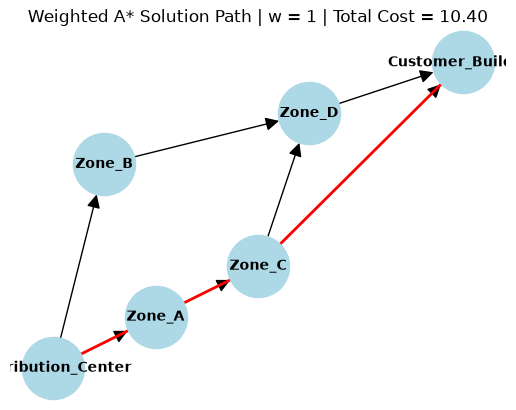

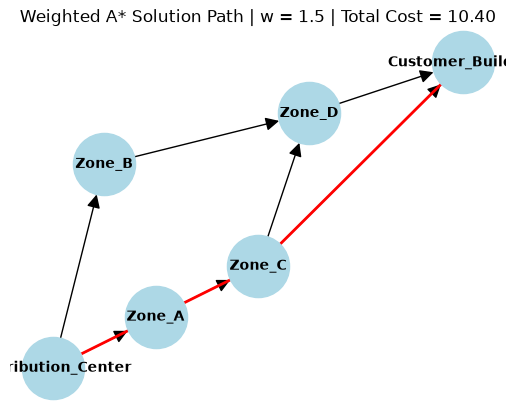

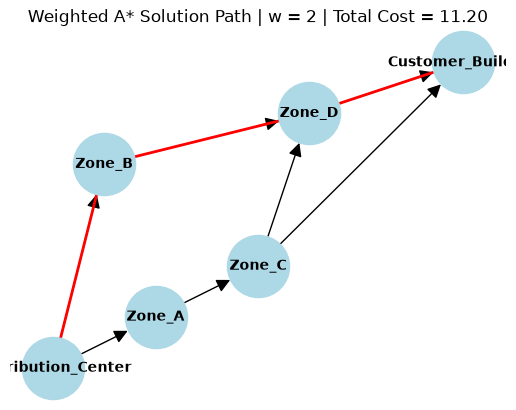

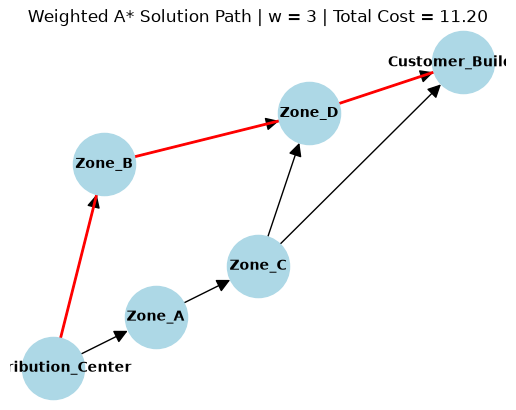

In [38]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create NetworkX Graph

G = nx.DiGraph()

# Add nodes with their coordinates
for node, position in locations.items():

    G.add_node(
        node,
        pos=position
    )


# Add weighted edges
for node, neighbors in graph.items():

    for neighbor, cost in neighbors.items():
        G.add_edge(
            node,
            neighbor,
            weight=cost
        )


        

# 2. Node Positions
pos = locations

# 3. Visualize Weighted A* Result for Each Weight

for w in weights:

    # Run Weighted A*
    path, cost, expansion_order = weighted_a_star(
        start,
        goal,
        graph,
        w
    )

    nx.draw_networkx(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
    path_edges = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)
    
    
    plt.title(
        f"Weighted A* Solution Path | w = {w} | "
        f"Total Cost = {cost:.2f}"
    )

    plt.axis("off")

    plt.show()

#### Expansion order

This means:

In what order did the search algorithm remove/select nodes from the frontier and process them?

For example:

Expanded:
S → A → B → C → D → G

The algorithm may explore some nodes that are ultimately not part of the final route.

#### Solution path

This means:

Which nodes form the final route from start to goal?

For example:

Solution:
S → A → C → G

Here:

Expansion order:  S → A → B → C → D → G
Solution path:    S → A → C → G